# Quantum Teleportation


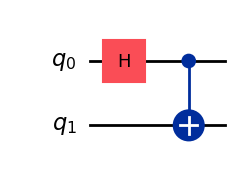

In [1]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)

qc.draw("mpl")

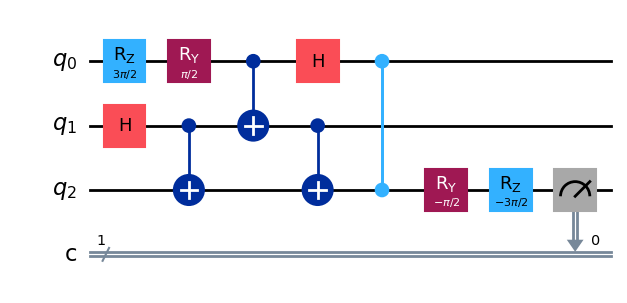

Measurement results (5000 shots):
{'0': 5000}


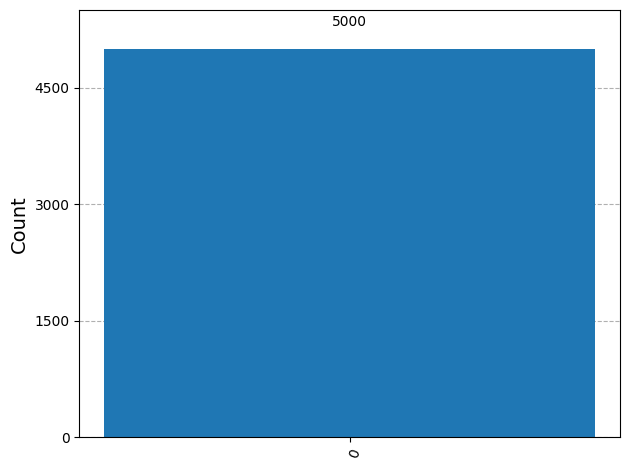

In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector

from qiskit.visualization import plot_bloch_multivector,plot_histogram
import matplotlib.pyplot as plt
import numpy as np

qc = QuantumCircuit(3,1)

theta = np.pi/2
phi = 3*np.pi/2

qc.rz(phi,0)
qc.ry(theta,0)



#creating of Bell States
qc.h(1)
qc.cx(1,2)


qc.cx(0,1)
qc.h(0)


qc.cx(1, 2)
qc.cz(0, 2)


qc.ry(-theta,2)
qc.rz(-phi,2)


qc.measure(2,0)

display(qc.draw("mpl"))

sim = AerSimulator()
result = sim.run(qc, shots=5000).result()
counts = result.get_counts()
print("Measurement results (5000 shots):")
print(counts)
plot_histogram(counts)

1. What do you observe in the histogram after applying U†? Is Bob measuring 0 with 100%
probability?

• In the histogram, I observe a single outcome: the state |0⟩ with 100% probability.  
• Yes, Bob measures |0⟩ with complete certainty across all 5000 shots. This is the
expected result the protocol successfully teleported the arbitrary state |ψ⟩ to
Bob's qubit, and the subsequent inverse operation U† rotated it back to the
ground state |0⟩.

2. Why does applying U† verify teleportation? Use U†U = I in your explanation.

The Power of the Inverse: Verification hinges on the fact that every unitary operation $U$ has a corresponding adjoint $U^\dagger$. Because $U^\dagger U = I$ (the identity matrix), applying $U^\dagger$ serves as a mathematical "undo" button that reverts any state transformation back to its original form.

State Preparation at Alice’s End: At the start of the experiment, Alice generates the unknown state $|\psi\rangle$ by applying $U$ to a known ground state, expressed as $|\psi\rangle = U|0\rangle$. For teleportation to be considered a success, this specific state must be perfectly reconstructed at Bob's location.

Bob’s Mathematical Proof: Once the protocol is complete and Bob receives the state, he applies $U^\dagger$. If teleportation worked, the calculation follows as $U^\dagger |\psi\rangle = U^\dagger (U|0\rangle) = (U^\dagger U)|0\rangle = I|0\rangle = |0\rangle$. This operation effectively translates the complex state $|\psi\rangle$ back into the measurable ground state $|0\rangle$.

Confirmation through Measurement: The final proof is found in the measurement result. If Bob consistently measures $|0\rangle$, it guarantees that his qubit held the exact state $|\psi\rangle$ before the inverse was applied. Any other result would indicate a failure in the transfer, confirming that the state was preserved across the quantum channel.

3. Why were we able to avoid sending classical bits? How does the fully quantum correction differ from the real protocol?

we never measure qubits q0 and q1 after performing the Bell-state operations. Since no measurement is performed, no classical bits are generated, and therefore no classical communication is required.

Instead of measuring and conditionally applying corrections, the circuit applies:

qc.cx(1, 2)
qc.cz(0, 2)

These gates act as quantum-controlled corrections. The qubits q0 and q1 themselves control the required Pauli corrections on Bob’s qubit (q2).

Because the system remains fully quantum and unitary throughout the circuit, the corrections are applied coherently. This replaces classical control (based on measurement outcomes) with quantum control (using entanglement and controlled gates).

In the real teleportation protocol, Alice measures her qubits and sends two classical bits to Bob, who then applies classically controlled
𝑋
X and
𝑍
Z gates. In this implementation, measurement is postponed until the very end, and corrections are applied entirely within the quantum circuit. This works in simulation but differs from the real protocol, where classical communication between distant parties is essential.

# Superdense Coding (Bell State)

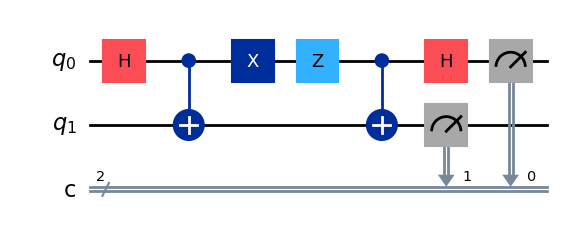

Measurement results (1 shot):
{'11': 1}


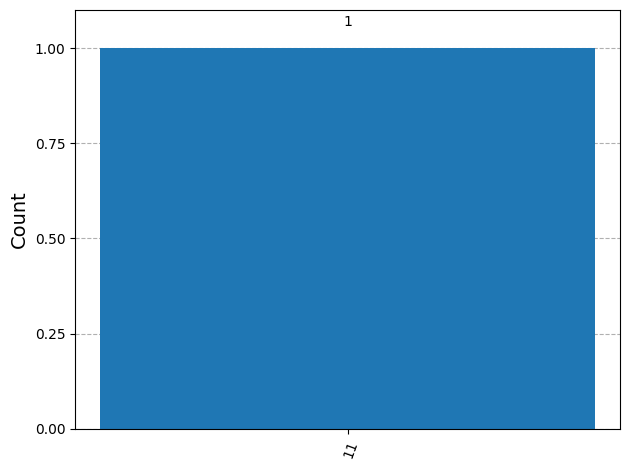

In [6]:
qc = QuantumCircuit(2,2)

#creating of Bell States
qc.h(0)
qc.cx(0,1)

qc.x(0)
qc.z(0)


qc.cx(0,1)
qc.h(0)

qc.measure([0,1],[0,1])

display(qc.draw("mpl"))

sim = AerSimulator()
result = sim.run(qc, shots=1).result()
counts = result.get_counts()
print("Measurement results (1 shot):")
print(counts)
plot_histogram(counts)


1. What happens if an eavesdropper intercepts the qubit sent from Alice to Bob?

In the teleportation protocol, the qubit sent from Alice to Bob is not the original quantum state
∣
𝜓
⟩
∣ψ⟩. It is part of an entangled Bell pair and, by itself, contains no usable information about the state.

If an eavesdropper intercepts Bob’s qubit before classical correction, the reduced density matrix of that qubit is maximally mixed
	​


This means it appears completely random when measured.

Any measurement performed by the eavesdropper collapses the entangled state, disturbing the global quantum system. As a result, the teleportation will fail, and Bob will not recover the correct state after corrections.

Therefore, the eavesdropper gains no information about
∣
𝜓
⟩
∣ψ⟩, but their interference introduces detectable errors. This is a direct consequence of entanglement and the no-cloning principle in quantum mechanics.

2. Give one application or implication of superdense coding.

Efficient Classical Communication:
Superdense coding allows the transmission of 2 classical bits by sending only 1 qubit, provided Alice and Bob share prior entanglement.

Bandwidth Optimization:
This effectively doubles the classical communication capacity of a quantum channel compared to a classical channel of the same size.

Application – Quantum Networks:
In future quantum communication systems and quantum internet architectures, superdense coding can reduce transmission cost while maximizing data throughput.

Implication:
It demonstrates how entanglement acts as a communication resource, showing that shared entanglement can enhance classical information capacity beyond classical limits.